In [12]:
import os
os.chdir('/fast/pmayilvahanan/post_training/dapo/verl/notebooks/')
from utils import hf_tokenizer
import torch
from utils import compute_pass_at_k, load_advantages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tokenizer = hf_tokenizer('Qwen/Qwen2.5-1.5B')

In [2]:
base_dir = '/fast/pmayilvahanan/post_training/verl_checkpoints/self_distillation/Qwen/'
# checkpoints = {
#     'qwen': os.path.join(base_dir, 'Qwen2.5-1.5B_openai_math_n_32_bsz_512_epochs_10_kl_coef_0.0'),
# }

checkpoints = {
    'qwen': os.path.join(base_dir, 'Qwen2.5-7B_openai_math_n_8_bsz_512_epochs_10_kl_coef_0.0'),
}

In [8]:
len(advantages['qwen']['samples'][0])

8

In [4]:
rl_0  = {}
rl_1  = {}

In [3]:
#epochs = [-1, 10, 20, 30, 40, 50, 60, 70]
epochs = [-1]
for adv_type in ['train']:
    for epoch in epochs:
        if epoch == -1:
            epoch = None
        rl_0[epoch] = []
        rl_1[epoch] = []
        advantages = load_advantages(checkpoints, split=adv_type, epoch=epoch)
        total_samples = 0
        for key in advantages['qwen']['samples'].keys():
            sample = advantages['qwen']['samples'][key]
            total_samples += 1
            if total_samples % 1000 == 0:
                print(f'{total_samples} samples processed')
            if sample[0]['advantage'] == 0.0:
                continue
            for obs in sample:
                if obs['advantage'] < 0.0:
                    rl_0[epoch].append(len(tokenizer.encode(obs['response'])))
                elif obs['advantage'] > 0.0:
                    rl_1[epoch].append(len(tokenizer.encode(obs['response'])))
                else:
                    continue
                

NameError: name 'rl_0' is not defined

In [18]:
rl_1_val = {}
rl_0_val = {}
for adv_type in ['val']:
    for epoch in [-1, 10, 20, 30, 40, 50, 60, 70]:
        if epoch == -1:
            epoch = None
        rl_0_val[epoch] = []
        rl_1_val[epoch] = []
        advantages = load_advantages(checkpoints, split=adv_type, epoch=epoch)
        total_samples = 0
        for key in advantages['qwen']['samples'].keys():
            sample = advantages['qwen']['samples'][key]
            total_samples += 1
            if total_samples % 500 == 0:
                print(f'{total_samples} samples processed')
            if sample[0]['advantage'] == 0.0:
                continue
            for obs in sample:
                if obs['advantage'] < 0.0:
                    rl_0_val[epoch].append(len(tokenizer.encode(obs['response'])))
                elif obs['advantage'] > 0.0:
                    rl_1_val[epoch].append(len(tokenizer.encode(obs['response'])))
                else:
                    continue
                

In [25]:
advantages

In [11]:
rl_1[0] = rl_1[None]

In [14]:
x = [10, 20, 30, 40, 50, 60, 70]

In [22]:
plt.plot(x, [np.mean(rl_1[step]) for step in x], label = 'train')
plt.plot(x, [np.mean(rl_1_val[step]) for step in x], label = 'val')
plt.legend()
plt.title("Response length of correct traces")

In [23]:
plt.plot(x, [np.mean(rl_0[step]) for step in x], label = 'train')
plt.plot(x, [np.mean(rl_0_val[step]) for step in x], label = 'val')
plt.legend()
plt.title("Response length of incorrect traces")

In [17]:
len(advantages['val'][None]['qwen']['samples'][2])

In [2]:
import pickle
import os
os.chdir('/fast/pmayilvahanan/post_training/dapo/verl/notebooks/')
from utils import process_training_results
dir = '/fast/pmayilvahanan/post_training/verl_checkpoints/self_distillation/Qwen/Qwen2.5-1.5B_openai_math_n_32_bsz_512_epochs_10_kl_coef_0.0/scores_response_length/'
train_aggregated_results = pickle.load(open(os.path.join(dir, 'train_aggregated_results.pkl'), 'rb'))
df_train = process_training_results(train_aggregated_results)
df_train.head()

step_metrics = df_train.groupby('step').agg({
    'pass@1mean@32': 'mean',
    'pass@32': 'mean'
}).reset_index()

# Rename columns for clarity
step_metrics.rename(columns={
    'pass@1mean@32': 'avg_pass@1',
    'pass@32': 'avg_pass@32'
}, inplace=True)

In [10]:
import seaborn as sns
sample_id = 8000
sample_data = df_train[df_train['sample_id'] == sample_id].melt(
    id_vars=['step'], 
    value_vars=['correct_resp_length', 'incorrect_resp_length'],
    var_name='response_type', 
    value_name='length'
)
sns.lineplot(
    data=sample_data, 
    x='step', 
    y='length', 
    hue='response_type', 
    markers=True, 
    dashes=False,
    palette={'correct_resp_length': 'green', 'incorrect_resp_length': 'red'}
).set(title=f'Response Lengths for Sample {sample_id}')

In [ ]:
import seaborn as sns
sample_id = 8000
sample_data = df_train[df_train['sample_id'] == sample_id].melt(
    id_vars=['step'], 
    value_vars=['correct_resp_length', 'incorrect_resp_length'],
    var_name='response_type', 
    value_name='length'
)
sns.lineplot(
    data=sample_data, 
    x='step', 
    y='length', 
    hue='response_type', 
    markers=True, 
    dashes=False,
    palette={'correct_resp_length': 'green', 'incorrect_resp_length': 'red'}
).set(title=f'Response Lengths for Sample {sample_id}')

In [13]:
step_metrics.head()

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.lineplot(data=step_metrics.melt(id_vars=['step'], 
                                    value_vars=['avg_pass@1', 'avg_pass@32'],
                                    var_name='metric', 
                                    value_name='rate'), 
             x='step', y='rate', hue='metric', marker='o')
plt.title('Average Pass Metrics Across Training Steps')
plt.xlabel('Training Step')
plt.ylabel('Pass Rate')
plt.grid(True)
plt.show()

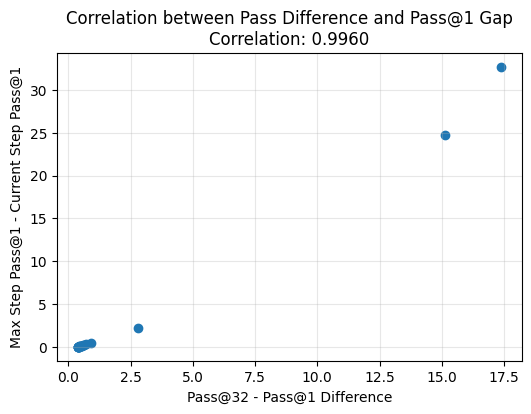

In [12]:
# Create column for difference between avg_pass@32 and avg_pass@1
step_metrics['pass_diff'] = (step_metrics['avg_pass@32'] - step_metrics['avg_pass@1']) / step_metrics['avg_pass@1']

# Get the avg_pass@1 value for the highest step
max_step = step_metrics.index.max()
max_step_pass1 = step_metrics.loc[max_step, 'avg_pass@1']

# Create column for difference between highest step's avg_pass@1 and each step's avg_pass@1
step_metrics['pass1_from_max'] = (max_step_pass1 - step_metrics['avg_pass@1']) / step_metrics['avg_pass@1']

# Create scatterplot and calculate correlation
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlation coefficient
corr = np.corrcoef(step_metrics['pass_diff'], step_metrics['pass1_from_max'])[0, 1]

# Create scatterplot
plt.figure(figsize=(6, 4))
plt.scatter(step_metrics['pass_diff'], step_metrics['pass1_from_max'])
#plt.xscale('log')  # Set x-axis to logarithmic scale
plt.xlabel('Pass@32 - Pass@1 Difference')
plt.ylabel('Max Step Pass@1 - Current Step Pass@1')
plt.title(f'Correlation between Pass Difference and Pass@1 Gap\nCorrelation: {corr:.4f}')
plt.grid(True, alpha=0.3)

In [4]:
step_metrics

,step,avg_pass@1,avg_pass@32,pass_diff,pass1_from_max
0,0,0.018235,0.335007,0.316772,0.596558
1,5,0.023865,0.385045,0.361180,0.590928
2,10,0.192365,0.733817,0.541452,0.422427
3,15,0.430394,0.822173,0.391779,0.184399
4,20,0.487293,0.831287,0.343994,0.127500
5,25,0.514951,0.837798,0.322847,0.099842
6,30,0.535191,0.846075,0.310884,0.079601
7,35,0.552037,0.848121,0.296084,0.062756
8,40,0.564828,0.850725,0.285897,0.049965
9,45,0.577204,0.851749,0.274545,0.037589
